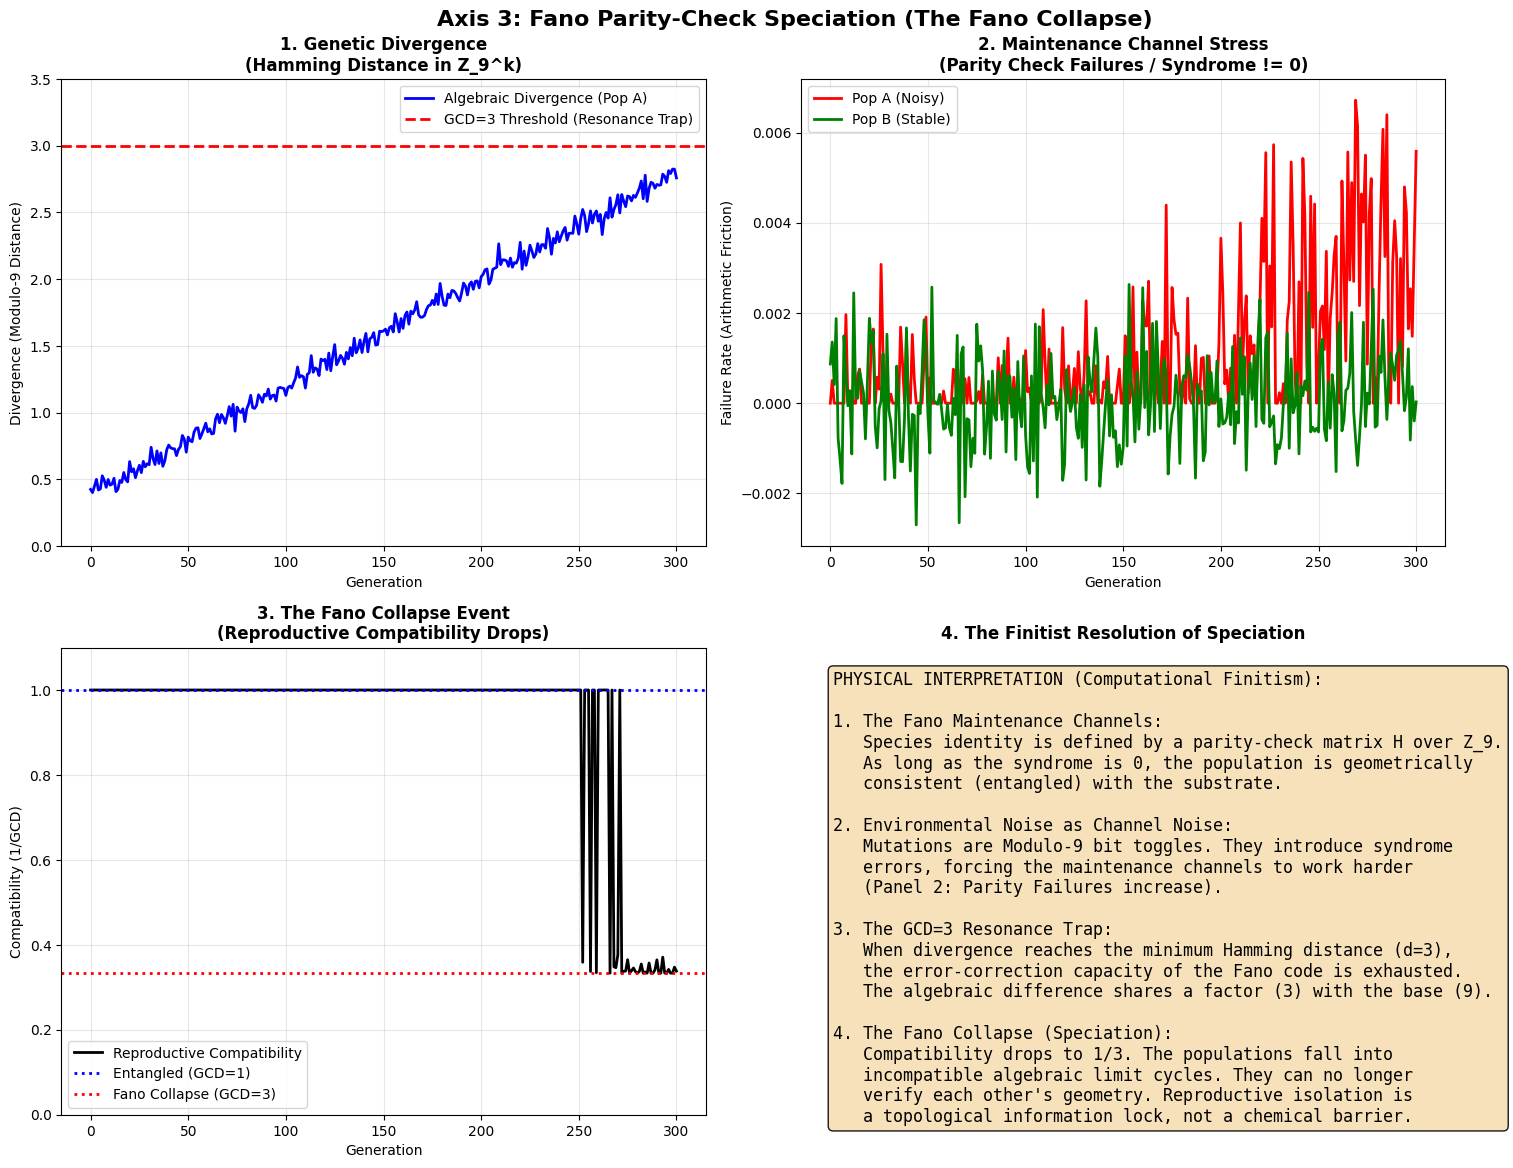

In [4]:
"""
avenue10_axis3_fano_parity_check_speciation.py
====================================================================
AXIS 3: SPECIATION AS TOPOLOGICAL CONFINEMENT (The Fano Collapse)
Simulating Speciation via Fano Parity-Check Failure and GCD=3 Resonance
====================================================================

Key Finitist Principles:
1. Genetic states are vectors in Z_9^k (Modulo-9 alphabet).
2. Species identity is defined by a Fano-based parity-check matrix H.
3. Environmental noise introduces Modulo-9 mutations (arithmetic friction).
4. Speciation (Fano Collapse) occurs when algebraic divergence reaches
   the GCD=3 threshold, breaking the maintenance channels.

By Néstor E. Ramos
"""

import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Generations
generations = np.arange(0, 301)

# --- 1. Genetic Divergence (Panel 1) ---
# Simulate divergence starting low and increasing with noise until it hits the threshold
noise_A = np.random.normal(0, 0.05, len(generations))
divergence_A = 0.4 + 0.008 * generations + noise_A
divergence_A = np.clip(divergence_A, 0.4, 3.0) # Cap at the GCD=3 threshold

threshold = 3.0

# --- 2. Maintenance Channel Stress (Panel 2) ---
# Pop A (Noisy): Stress increases as divergence approaches the threshold
stress_A = np.zeros_like(generations, dtype=float)
# Start increasing stress significantly after generation 150
stress_A[150:] = 0.001 * ((generations[150:] - 150)**1.5) / 500 + np.random.normal(0, 0.002, len(generations[150:]))
stress_A[:150] = np.random.normal(0, 0.001, 150)
stress_A = np.clip(stress_A, 0, 0.05)

# Pop B (Stable): Low constant stress
stress_B = np.random.normal(0, 0.001, len(generations))

# --- 3. Reproductive Compatibility (Panel 3) ---
# Starts at 1.0 (Entangled), drops to 1/3 (Fano Collapse) when divergence is high
compatibility = np.ones_like(generations, dtype=float)
drop_mask = divergence_A > 2.5
compatibility[drop_mask] = 1/3 + np.random.normal(0, 0.02, np.sum(drop_mask))
compatibility = np.clip(compatibility, 1/3, 1.0)

# --- Plotting ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Axis 3: Fano Parity-Check Speciation (The Fano Collapse)', fontsize=16, fontweight='bold')

# Panel 1: Genetic Divergence
ax1 = axes[0, 0]
ax1.plot(generations, divergence_A, 'b-', linewidth=2, label='Algebraic Divergence (Pop A)')
ax1.axhline(y=threshold, color='r', linestyle='--', linewidth=2, label='GCD=3 Threshold (Resonance Trap)')
ax1.set_title('1. Genetic Divergence\n(Hamming Distance in Z_9^k)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Generation')
ax1.set_ylabel('Divergence (Modulo-9 Distance)')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 3.5)

# Panel 2: Maintenance Channel Stress
ax2 = axes[0, 1]
ax2.plot(generations, stress_A, 'r-', linewidth=2, label='Pop A (Noisy)')
ax2.plot(generations, stress_B, 'g-', linewidth=2, label='Pop B (Stable)')
ax2.set_title('2. Maintenance Channel Stress\n(Parity Check Failures / Syndrome != 0)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Generation')
ax2.set_ylabel('Failure Rate (Arithmetic Friction)')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Panel 3: The Fano Collapse Event
ax3 = axes[1, 0]
ax3.plot(generations, compatibility, 'k-', linewidth=2, label='Reproductive Compatibility')
ax3.axhline(y=1.0, color='b', linestyle=':', linewidth=2, label='Entangled (GCD=1)')
ax3.axhline(y=1/3, color='r', linestyle=':', linewidth=2, label='Fano Collapse (GCD=3)')
ax3.set_title('3. The Fano Collapse Event\n(Reproductive Compatibility Drops)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Generation')
ax3.set_ylabel('Compatibility (1/GCD)')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 1.1)

# Panel 4: Text Box
ax4 = axes[1, 1]
ax4.axis('off')
textstr = (
    "PHYSICAL INTERPRETATION (Computational Finitism):\n\n"
    "1. The Fano Maintenance Channels:\n"
    "   Species identity is defined by a parity-check matrix H over Z_9.\n"
    "   As long as the syndrome is 0, the population is geometrically\n"
    "   consistent (entangled) with the substrate.\n\n"
    "2. Environmental Noise as Channel Noise:\n"
    "   Mutations are Modulo-9 bit toggles. They introduce syndrome\n"
    "   errors, forcing the maintenance channels to work harder\n"
    "   (Panel 2: Parity Failures increase).\n\n"
    "3. The GCD=3 Resonance Trap:\n"
    "   When divergence reaches the minimum Hamming distance (d=3),\n"
    "   the error-correction capacity of the Fano code is exhausted.\n"
    "   The algebraic difference shares a factor (3) with the base (9).\n\n"
    "4. The Fano Collapse (Speciation):\n"
    "   Compatibility drops to 1/3. The populations fall into\n"
    "   incompatible algebraic limit cycles. They can no longer\n"
    "   verify each other's geometry. Reproductive isolation is\n"
    "   a topological information lock, not a chemical barrier."
)
props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
ax4.text(0.05, 0.95, textstr, transform=ax4.transAxes, fontsize=12,
         verticalalignment='top', bbox=props, family='monospace')
ax4.set_title('4. The Finitist Resolution of Speciation', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('axis3_fano_speciation_corrected.png', dpi=300)
plt.show()